In [1]:
import matplotlib.pyplot as plt
import plot
from variance_stabilizing import *

In [2]:
N = [10, 5, 1]
df = chi2(
    size=2**12,
    N=N,
    sigmas=np.linspace(0, 5, 20),
)

In [3]:
improvement = (
    1
    / df.groupby(["sigma", "variant", "N"])
    .RMSE.mean()
    .reset_index()
    .groupby(["variant", "N"])
    .RMSE.min()
).unstack()

improvement.loc["Z-score"] / improvement.loc["Anscombe"]

N
1     1.753786
5     1.108645
10    1.045565
dtype: float64

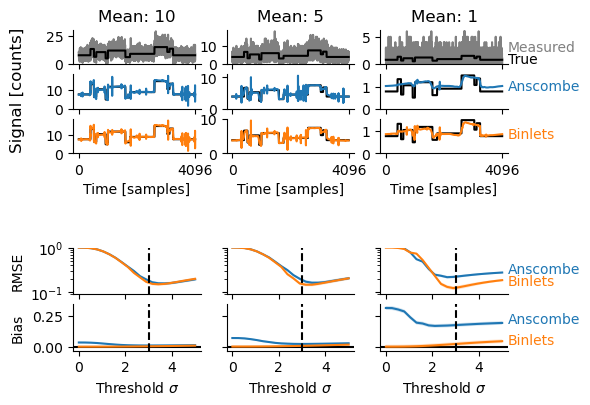

In [4]:
def panel_A(axes: Figure, N, sigma, size):
    x_true = generate_true(N=N, size=size)
    x_noisy = np.random.default_rng(42).poisson(x_true)
    axes[0].plot(x_true, color="black", label="True", zorder=1)
    axes[0].plot(x_noisy, color="gray", label="Measured", zorder=0)
    for ax in axes[1:]:
        ax.plot(x_true, color="black")
    axes[1].plot(binlets_anscombe(x_noisy, sigma=sigma), color="C0", label="Anscombe")
    axes[2].plot(binlets_zscore(x_noisy, sigma=sigma), color="C1", label="Binlets")
    axes[0].set(xticks=(0, len(x_true)))
    for ax in axes:
        ax.set(ylim=(0, None))


def panel_B(fig_or_axes, df, y):
    (
        so.Plot(df, x="sigma", y=y, color="variant")
        .label(x="Threshold $\sigma$", y="")
        .add(so.Line(), so.Est())
        .add(so.Band(alpha=1), so.Est(errorbar="se"))
        .add(so.Band(), so.Est(errorbar="sd"))
        .theme(plt.rcParams)
        .on(fig_or_axes)
        .plot()
    )


fig = plt.figure(figsize=(6, 4))
fig.subplots_adjust(right=0.85, bottom=0.3)
fig_signal, _fig, fig_chi = fig.subfigures(3, height_ratios=[1.2, 0.05, 1])
_fig.set_visible(False)

sigma = 3

axes = fig_signal.subplots(3, 3, sharex=True, gridspec_kw=dict(hspace=0.3))
for ax in axes.flat:
    seaborn.despine(ax=ax, top=True, right=True)

fig_signal.supylabel("Signal [counts]", y=0.6, va="center")
for axcol, Ni in zip(axes.T, N):
    axcol[0].set(title=f"Mean: {Ni}")
    axcol[-1].set(xlabel="Time [samples]")
    panel_A(axcol, N=Ni, sigma=sigma, size=2**12)

plot.label_lines(axes[0,-1], offsets=[0, 2])
for ax in axes[1:,-1]:
    plot.label_lines(ax)

axes = fig_chi.subplots(2, 3, sharex=True, sharey="row")
for ax in axes.flat:
    seaborn.despine(ax=ax, top=True, right=True)

for ax, (_, dg) in zip(axes.T[::-1], df.groupby("N", sort=True)):
    panel_B(ax[0], dg, y="RMSE")
    panel_B(ax[1], dg, y="bias")
    for a in ax:
        a.axvline(sigma, linestyle="--", color="black")
    ax[1].axhline(0, linestyle="-", color="black", zorder=-1)
    ax[0].set(xlabel="")

axes[0,0].set(yscale="log")
axes[0,0].set(ylabel="RMSE", ylim=(0.09, 1))
axes[1,0].set(ylabel="Bias")

fig_chi.legends = []
plot.label_lines(axes[0,-1], labels=["Anscombe", "Binlets"], offsets=[0.05, -0.01])
plot.label_lines(axes[1,-1], labels=["Anscombe", "Binlets"], offsets=[0.03, 0.01])
fig_chi.align_ylabels()

path = "../article/figures/2_variance_stabilizing"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")